In [8]:
from skimage.metrics import structural_similarity 
import imutils
import cv2
from PIL import Image
import requests

In [9]:
# Open the image and display
# stream=True -> Get the image without save it
# .raw -> Get the image information from internet
original = Image.open(requests.get('https://www.thestatesman.com/wp-content/uploads/2019/07/pan-card.jpg', stream=True).raw)
tampered = Image.open(requests.get('https://assets1.cleartax-cdn.com/s/img/20170526124335/Pan4.png', stream=True).raw)

In [10]:
# The file format of the source file
print("Original image format: ", original.format)
print("Tampered image format: ", tampered.format)

print('--------------------------------')

# Image size, in pixels. The size is given as a tuple (width, height)
print("Original image size: ", original.size)
print("Tampered image size: ", tampered.size)

Original image format:  JPEG
Tampered image format:  PNG
--------------------------------
Original image size:  (1200, 800)
Tampered image size:  (282, 179)


In [ ]:
# Resize Image
original = original.resize((280,160))
print("Original size: ", original.size)
original.save("C:/Users/Dule/Desktop/pan_card_tampering/image_1/original.png") # Save image

tampered = tampered.resize((280,160))
print("Tampered size: ", tampered.size)
tampered.save("C:/Users/Dule/Desktop/pan_card_tampering/image_1/tampered.png") # Save image


Original size:  (280, 160)
Tampered size:  (280, 160)


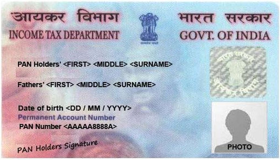

In [12]:
original

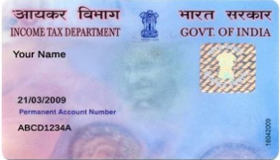

In [13]:
tampered

In [15]:
# load the two input images
original  = cv2.imread("C:/Users/Dule/Desktop/pan_card_tampering/image_1/original.png")
tampered = cv2.imread("C:/Users/Dule/Desktop/pan_card_tampering/image_1/tampered.png")

In [16]:
# Convert the images to grayscale
original_gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
tampered_gray = cv2.cvtColor(tampered, cv2.COLOR_BGR2GRAY)

In [18]:
# Compute the Structural Similarity Index (SSIM) between the two images, ensuring that the difference image is returned
(score, diff) = structural_similarity(original_gray, tampered_gray, full=True)
diff = (diff * 255).astype("uint8")
print(f"SSIM: {score}")

SSIM: 0.3182788854419573


In [20]:
# Calculating threshold and contours
thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)


In [21]:
# loop over the contours
for c in cnts:
    # applaying contours on image
    (x,y,w,h) = cv2.boundingRect(c)
    cv2.rectangle(original, (x,y), (x + w, y + h), (0, 0, 255), 2)
    cv2.rectangle(tampered, (x,y), (x + w, y + h), (0, 0, 255), 2)

Original Format Image


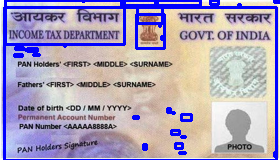

In [26]:
# Display original image with the contour
print("Original Format Image")
Image.fromarray(original)

Tampared Format Image


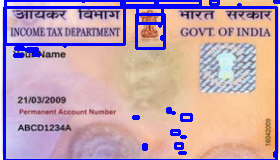

In [27]:
# Display tampared image with the contour
print("Tampared Format Image")
Image.fromarray(tampered)

Different Image


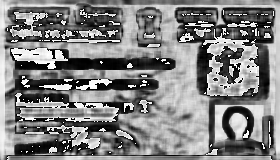

In [29]:
# ALL THE BLACK IS THE DIFFERENCE -> 100% FAKE 

# Display difference image with black
print("Different Image")
Image.fromarray(diff)

Threshold Image


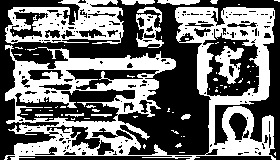

In [ ]:
# ALL THE WHITE IS THE DIFFERENCE -> 100% FAKE 

# Display difference image with white
print("Threshold Image")
Image.fromarray(thresh)